# CAPE-k Cloud Phase & Thermodynamics — Kennaook / Cape Grim, Tasmania

**Southern Ocean mixed-phase cloud case study — 15 September 2025**

This notebook pairs the ARM **THERMOCLDPHASE** value-added product (vertically resolved
thermodynamic cloud phase) with **TROPoe** (the AERI optimal-estimation temperature/humidity
retrieval, successor to AERIoe) and NCEP/NCAR Reanalysis synoptic maps, for the CAPE-k
deployment at Kennaook / Cape Grim on the north-west tip of Tasmania (40.68 °S, 144.69 °E).

**Campaign:** CAPE-k — Cloud And Precipitation Experiment at Kennaook (ARM AMF2, Apr 2024 – Oct 2025).

## What this notebook shows

1. Download THERMOCLDPHASE and TROPoe from the ARM Live API.
2. A three-panel time–height curtain: KAZR reflectivity, cloud phase, and AERI temperature,
   with the AERI 0 °C isotherm threaded across all panels.
3. A quantitative phase–temperature consistency check (ice above 0 °C, supercooled liquid below cloud top).
4. The Southern Ocean synoptic setting (MSLP, near-surface temperature, 10 m winds) from NCEP/NCAR Reanalysis.

## Why 15 September 2025?

Across the deployment this day has the richest co-available cloud scene — the highest cloud
fraction among days with **both** THERMOCLDPHASE and TROPoe, all seven hydrometeor phases
present, a deep ice canopy over a supercooled-liquid / mixed-phase band, driven by a
frontal system on the north-east flank of a deep Southern Ocean low.

---
*Co-authored by Scott Collis and Claude.*

## 1. Setup and credentials

The ARM Live token is read from environment variables (`ARM_USERNAME`, `ARM_TOKEN`) or, failing
that, prompted interactively with `getpass`. **The token is never hardcoded** — this notebook is
committed to a public repository.

Get a token at <https://adc.arm.gov/armlive/> (log in — your token is shown on the page).

In [1]:
import os
import getpass
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm

# cmweather registers the ChaseSpectral radar colormap on import
import cmweather  # noqa: F401

# ARM Live credentials — from env, else prompt (never hardcode)
ARM_USERNAME = os.environ.get("ARM_USERNAME") or getpass.getpass("ARM username: ")
ARM_TOKEN = os.environ.get("ARM_TOKEN") or getpass.getpass("ARM Live token: ")
ARM_USER = f"{ARM_USERNAME}:{ARM_TOKEN}"

OUTDIR = Path("CAPE_k_cloud_phase_outputs"); OUTDIR.mkdir(exist_ok=True)
DATADIR = Path("cape_k_data"); DATADIR.mkdir(exist_ok=True)

# Site + case
SITE_LAT, SITE_LON = -40.68078, 144.68983   # Kennaook / Cape Grim (datastream global attrs)
CASE_DAY = "2025-09-15"

## 2. Download the ARM data

We use the ACT (Atmospheric data Community Toolkit) ARM Live downloader,
`act.discovery.download_arm_data`, which wraps the ARM Live REST webservice. Two datastreams are
used, both from facility **M1** at site **kcg** (Kennaook / Cape Grim):

| Datastream | Product |
|---|---|
| `kcgthermocldphaseM1.c0` | THERMOCLDPHASE — thermodynamic cloud phase (evaluation level) |
| `kcgtropoeM1.c1` | TROPoe — AERI optimal-estimation T/q profiles |

> **Note on the AERI product name.** There is no `aerioe` datastream for CAPE-k. ARM replaced the
> older AERIoe VAP with **TROPoe** (Tropospheric Remotely Observed Profiling via Optimal
> Estimation), which delivers the same AERI-based optimal-estimation retrieval under the new name.

In [2]:
from act.discovery import download_arm_data

def get_case_file(datastream):
    """Download the CASE_DAY file for a datastream via ACT and return its local path."""
    files = download_arm_data(ARM_USERNAME, ARM_TOKEN, datastream,
                              CASE_DAY, CASE_DAY, output=str(DATADIR / datastream))
    ymd = CASE_DAY.replace("-", "")
    match = [f for f in files if ymd in f]
    return match[0] if match else files[0]

tcp_file = get_case_file("kcgthermocldphaseM1.c0")
tro_file = get_case_file("kcgtropoeM1.c1")
print("THERMOCLDPHASE:", Path(tcp_file).name)
print("TROPoe        :", Path(tro_file).name)

[DOWNLOADING] kcgthermocldphaseM1.c0.20250915.000000.nc

If you use these data to prepare a publication, please cite:

Zhang, D., & Levin, M. Thermodynamic Cloud Phase (THERMOCLDPHASE), 2025-09-15 to
2025-09-15, ARM Mobile Facility (KCG), kennaook ⁄ Cape Grim, Tasmania,
Australia; AMF2 (main site for CAPE-k) (M1). Atmospheric Radiation Measurement
(ARM) User Facility. https://doi.org/10.5439/3022391

[DOWNLOADING] kcgtropoeM1.c1.20250915.000502.nc

If you use these data to prepare a publication, please cite:

Turner, D. Tropospheric Optimal Estimation Retrieval (TROPOE), 2025-09-15 to
2025-09-15, ARM Mobile Facility (KCG), kennaook ⁄ Cape Grim, Tasmania,
Australia; AMF2 (main site for CAPE-k) (M1). Atmospheric Radiation Measurement
(ARM) User Facility. https://doi.org/10.5439/1996977

THERMOCLDPHASE: kcgthermocldphaseM1.c0.20250915.000000.nc
TROPoe        : kcgtropoeM1.c1.20250915.000502.nc


## 3. Load and inspect the cloud-phase product

THERMOCLDPHASE at CAPE-k is built without HSRL or MWR-LWP inputs, so the operative phase field
is `cloud_phase_mplgr` (MPL-gradient based). A few file-specific conventions worth knowing:

- The `height` coordinate is already in **km** (≈0.16–18) — do **not** divide by 1000.
- The `time` coordinate is usable directly; `time_offset` is stored as `datetime64` (not a
  timedelta), so do not add it to `base_time`.
- Phase is an integer flag 0–8.

In [3]:
dc = xr.open_dataset(tcp_file)
tc = pd.to_datetime(dc["time"].values)
hc = dc["height"].values.astype(float)           # km (already)
phc = np.ma.masked_invalid(dc["cloud_phase_mplgr"].values.astype(float))
zec = np.ma.masked_invalid(dc["radar_ze"].values)  # KAZR best-estimate reflectivity, dBZ

# phase flag definitions straight from the file
phase_var = dc["cloud_phase_mplgr"]
PHASE_NAMES = ["clear", "liquid", "ice", "mixed", "drizzle", "liq+driz", "rain", "snow", "unknown"]
print("flag_values  :", phase_var.attrs.get("flag_values"))
print("flag_meanings:", phase_var.attrs.get("flag_meanings"))
print("height (km)  : %.2f – %.2f" % (hc.min(), hc.max()))
print("time span    :", tc[0], "→", tc[-1], "(n=%d)" % len(tc))

flag_values  : [0 1 2 3 4 5 6 7 8]
flag_meanings: clear_sky liquid ice mixed_phase drizzle liquid_drizzle rain snow unknown
height (km)  : 0.16 – 18.01
time span    : 2025-09-15 00:00:00 → 2025-09-15 23:59:30 (n=2880)


## 4. Load the AERI (TROPoe) retrieval and compute the freezing level

TROPoe returns the retrieved thermodynamic profile (temperature, water vapor, RH, θ, dewpoint)
on a ~5-minute grid, plus retrieval diagnostics. We take the temperature field and, for each
profile, find the lowest height where temperature crosses 0 °C — the freezing level that gives
the cloud-phase field its physical reference.

In [4]:
dt = xr.open_dataset(tro_file)
ttime = pd.to_datetime(dt["time"].values)
th = dt["height"].values.astype(float)        # km AGL
Temp = dt["temperature"].values                # (time, height) degC
conv = dt["converged_flag"].values

def freezing_level(prof, h):
    """Lowest height (km) where a temperature profile crosses 0 degC, linearly interpolated."""
    prof = np.asarray(prof); valid = np.isfinite(prof)
    if valid.sum() < 2:
        return np.nan
    p, hh = prof[valid], h[valid]
    for i in range(len(p) - 1):
        if p[i] >= 0 and p[i + 1] < 0:
            return hh[i] + (0 - p[i]) * (hh[i + 1] - hh[i]) / (p[i + 1] - p[i])
    return np.nan

fl = np.array([freezing_level(Temp[i], th) for i in range(Temp.shape[0])])
print("retrievals: %d  (%.0f%% converged)" % (len(ttime), 100 * np.mean(conv == 1)))
print("freezing level: median %.2f km  (range %.2f – %.2f km)"
      % (np.nanmedian(fl), np.nanmin(fl), np.nanmax(fl)))

retrievals: 218  (86% converged)
freezing level: median 2.70 km  (range 0.53 – 3.99 km)


## 5. Three-panel curtain — reflectivity, phase, and AERI temperature

Reflectivity uses cmweather's `ChaseSpectral`; phase uses a categorical map keyed to the flag
meanings; temperature uses a diverging map centered on 0 °C. The AERI 0 °C isotherm (dashed) is
overlaid on all three panels. To keep the time axes aligned, each panel reserves an identical
colorbar slot (invisible on the phase panel).

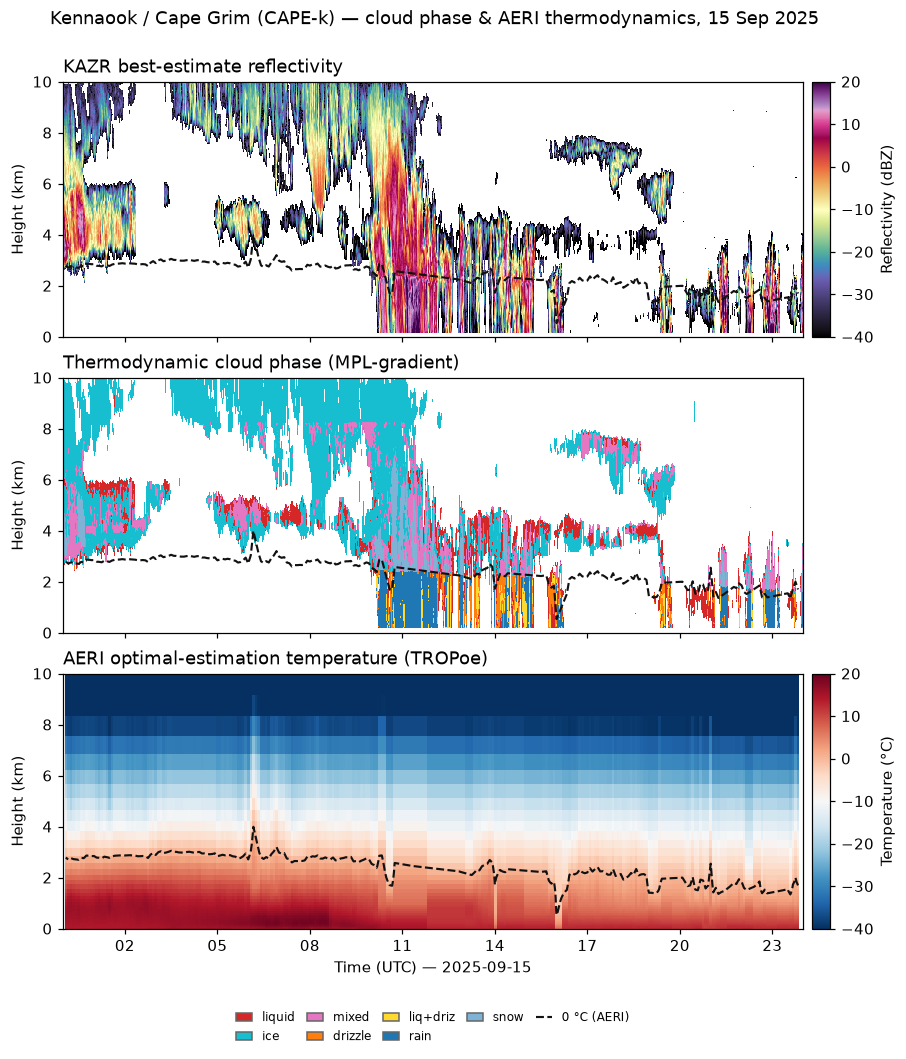

In [5]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# categorical phase colormap keyed to flag values 0..8
PHASE_COLORS = ["#ffffff", "#d62728", "#17becf", "#e377c2", "#ff7f0e",
                "#ffd92f", "#1f77b4", "#7fb3d5", "#bdbdbd"]
pcmap = ListedColormap(PHASE_COLORS)
pnorm = BoundaryNorm(np.arange(-0.5, 9.5, 1), pcmap.N)

kmax = np.searchsorted(hc, 10.0)          # Southern Ocean clouds are low: cap at 10 km
H, PH, ZE = hc[:kmax], phc[:, :kmax], zec[:, :kmax]
T = mdates.date2num(tc); Ttro = mdates.date2num(ttime)
tkmax = np.searchsorted(th, 10.0)
TH, TEMP = th[:tkmax], np.ma.masked_invalid(Temp[:, :tkmax])
FLC = "#111111"

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 10), sharex=True,
                                    gridspec_kw=dict(hspace=0.16))

def match_cbar(ax, mappable=None, label=None):
    cax = make_axes_locatable(ax).append_axes("right", size="2.5%", pad=0.08)
    if mappable is None:
        cax.set_visible(False); return None
    cb = fig.colorbar(mappable, cax=cax); cb.set_label(label); return cb

pm1 = ax1.pcolormesh(T, H, ZE.T, cmap="ChaseSpectral", vmin=-40, vmax=20, shading="nearest")
match_cbar(ax1, pm1, "Reflectivity (dBZ)")
ax1.set_ylabel("Height (km)"); ax1.set_ylim(0, 10)
ax1.set_title("KAZR best-estimate reflectivity", loc="left")
ax1.plot(Ttro, fl, color=FLC, lw=1.4, ls="--", zorder=6)

pm2 = ax2.pcolormesh(T, H, PH.T, cmap=pcmap, norm=pnorm, shading="nearest")
match_cbar(ax2, None)
ax2.set_ylabel("Height (km)"); ax2.set_ylim(0, 10)
ax2.set_title("Thermodynamic cloud phase (MPL-gradient)", loc="left")
ax2.plot(Ttro, fl, color=FLC, lw=1.4, ls="--", zorder=6)

pm3 = ax3.pcolormesh(Ttro, TH, TEMP.T, cmap="RdBu_r", vmin=-40, vmax=20, shading="nearest")
match_cbar(ax3, pm3, "Temperature (°C)")
ax3.contour(Ttro, TH, TEMP.T, levels=[0], colors=FLC, linewidths=1.4, linestyles="--")
ax3.set_ylabel("Height (km)"); ax3.set_ylim(0, 10)
ax3.set_title("AERI optimal-estimation temperature (TROPoe)", loc="left")
ax3.set_xlabel(f"Time (UTC) — {CASE_DAY}")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=3))

present = [i for i in range(1, 9) if np.sum(dc["cloud_phase_mplgr"].values[:, :kmax] == i) > 0]
handles = [Patch(facecolor=PHASE_COLORS[i], edgecolor="0.4", label=PHASE_NAMES[i]) for i in present]
handles.append(Line2D([0], [0], color=FLC, lw=1.4, ls="--", label="0 °C (AERI)"))
ax3.legend(handles=handles, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.28),
           frameon=False, handlelength=1.3, columnspacing=1.0, fontsize=8)

fig.suptitle("Kennaook / Cape Grim (CAPE-k) — cloud phase & AERI thermodynamics, "
             f"{pd.Timestamp(CASE_DAY):%d %b %Y}", y=0.945, fontsize=12)
fig.savefig(OUTDIR / "cape_k_thermocldphase_tropoe.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Phase–temperature consistency check

The phase VAP and the AERI retrieval are independent instruments (lidar/radar vs. infrared
interferometer). If they agree physically, ice should sit above the 0 °C isotherm and any liquid
above it is, by definition, **supercooled** — the Southern Ocean cloud signature CAPE-k targets.

In [6]:
# interpolate the AERI freezing level onto the phase time grid
fl_on_tc = np.interp(mdates.date2num(tc), Ttro, fl)
ph2 = dc["cloud_phase_mplgr"].values[:, :kmax]
Hg = np.broadcast_to(H, ph2.shape)
FLg = fl_on_tc[:, None]

ice_above = np.sum((ph2 == 2) & (Hg > FLg)) / max(np.sum(ph2 == 2), 1)
liq_above = np.sum((ph2 == 1) & (Hg > FLg)) / max(np.sum(ph2 == 1), 1)
print("ice cells above 0 °C   : %.1f%%" % (100 * ice_above))
print("liquid cells above 0 °C: %.1f%%  (= supercooled liquid)" % (100 * liq_above))

ice cells above 0 °C   : 99.7%
liquid cells above 0 °C: 77.7%  (= supercooled liquid)


## 7. Southern Ocean synoptic setting

To place the cloud scene in its weather context we pull **NCEP/NCAR Reanalysis 1** via OPeNDAP
from NOAA PSL and map mean sea-level pressure, near-surface air temperature, and 10 m winds over
the Australia / Southern Ocean sector. We use the 6-hourly fields at **12 UTC**.

- MSLP and near-surface temperature (`air.sig995`) are on the 2.5° grid.
- 10 m winds are only on the coarser Gaussian grid (`surface_gauss/`), thinned for legibility.

> **Cartopy note.** In a sandboxed environment `~/.local/share` may be read-only; point
> `cartopy.config['data_dir']` at a writable path before the first feature draw so Natural Earth
> shapefiles can be cached.

In [7]:
import cartopy
cartopy.config["data_dir"] = str((Path.cwd() / "cartopy_data").resolve())
Path(cartopy.config["data_dir"]).mkdir(exist_ok=True)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

B6 = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis"
t12 = pd.Timestamp(f"{CASE_DAY} 12:00")
latsl, lonsl = slice(-20, -70), slice(100, 180)      # NCEP lat is descending

slp6 = xr.open_dataset(f"{B6}/surface/slp.{t12.year}.nc")
air6 = xr.open_dataset(f"{B6}/surface/air.sig995.{t12.year}.nc")
uw = xr.open_dataset(f"{B6}/surface_gauss/uwnd.10m.gauss.{t12.year}.nc")
vw = xr.open_dataset(f"{B6}/surface_gauss/vwnd.10m.gauss.{t12.year}.nc")

slp12 = (slp6["slp"].sel(time=t12) / 100.0).sel(lat=latsl, lon=lonsl)          # hPa
air12 = air6["air"].sel(time=t12).sel(lat=latsl, lon=lonsl) - 273.15          # degC
u12 = uw["uwnd"].sel(time=t12).sel(lat=latsl, lon=lonsl)
v12 = vw["vwnd"].sel(time=t12).sel(lat=latsl, lon=lonsl)

slp00_site = float((slp6["slp"].sel(time=pd.Timestamp(f"{CASE_DAY} 00:00")) / 100.0)
                   .sel(lat=SITE_LAT, lon=SITE_LON, method="nearest"))
slp12_site = float(slp12.sel(lat=SITE_LAT, lon=SITE_LON, method="nearest"))
print("site MSLP  00 UTC: %.1f hPa   12 UTC: %.1f hPa   (%+.1f hPa)"
      % (slp00_site, slp12_site, slp12_site - slp00_site))

site MSLP  00 UTC: 1007.5 hPa   12 UTC: 1003.1 hPa   (-4.4 hPa)


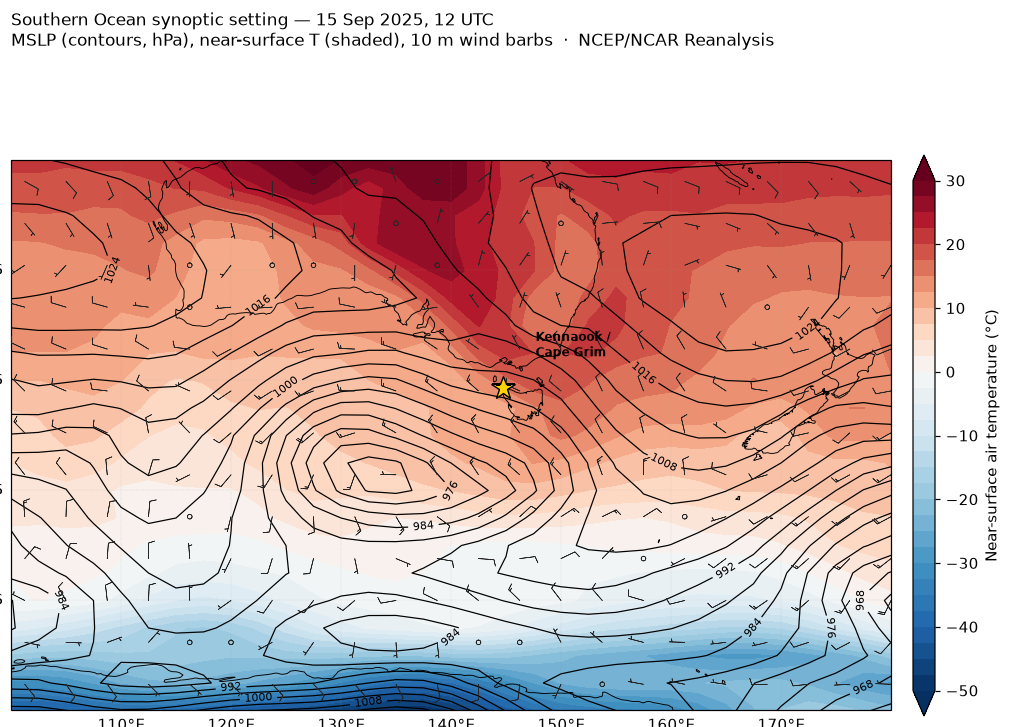

In [8]:
Lon, Lat = np.meshgrid(slp12.lon.values, slp12.lat.values)
ULon, ULat = np.meshgrid(u12.lon.values, u12.lat.values)

fig = plt.figure(figsize=(10, 7.5))
proj = ccrs.PlateCarree()
ax = fig.add_axes([0.06, 0.06, 0.80, 0.80], projection=proj)
cax = fig.add_axes([0.88, 0.12, 0.020, 0.68])
ax.set_extent([100, 180, -70, -20], crs=proj)

lv = np.arange(-50, 31, 2.5)
cf = ax.contourf(Lon, Lat, air12.values, levels=lv, cmap="RdBu_r",
                 norm=TwoSlopeNorm(vmin=-50, vcenter=0, vmax=30),
                 transform=proj, extend="both")
cb = fig.colorbar(cf, cax=cax, ticks=np.arange(-50, 31, 10))
cb.set_label("Near-surface air temperature (°C)")

cs = ax.contour(Lon, Lat, slp12.values, levels=np.arange(944, 1044, 4),
                colors="k", linewidths=0.8, transform=proj)
ax.clabel(cs, cs.levels[::2], fmt="%d", fontsize=7, inline=True)

st = 2   # thin the Gaussian-grid barbs
ax.barbs(ULon[::st, ::st], ULat[::st, ::st], u12.values[::st, ::st], v12.values[::st, ::st],
         length=4.5, linewidth=0.45, transform=proj, zorder=8, barbcolor="0.15", flagcolor="0.15")

ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.3, edgecolor="0.4")
gl = ax.gridlines(draw_labels=True, lw=0.3, color="0.6", alpha=0.5, ls=":")
gl.top_labels = gl.right_labels = False

ax.plot(SITE_LON, SITE_LAT, marker="*", ms=16, mfc="#ffd400", mec="black",
        mew=0.9, transform=proj, zorder=11)
ax.annotate("Kennaook /\nCape Grim", xy=(SITE_LON, SITE_LAT),
            xytext=(SITE_LON + 3, SITE_LAT + 2.5), transform=proj,
            fontsize=8, fontweight="bold", color="black", ha="left", va="bottom", zorder=11)

fig.suptitle(f"Southern Ocean synoptic setting — {pd.Timestamp(CASE_DAY):%d %b %Y}, 12 UTC\n"
             "MSLP (contours, hPa), near-surface T (shaded), 10 m wind barbs  ·  NCEP/NCAR Reanalysis",
             x=0.06, y=0.975, ha="left", fontsize=11)
fig.savefig(OUTDIR / "cape_k_synoptic_12z.png", dpi=200, bbox_inches=None)
plt.show()

## Summary

- **THERMOCLDPHASE** and **TROPoe** (the AERI optimal-estimation retrieval) both resolve the
  15 Sep 2025 frontal cloud at CAPE-k: a deep ice canopy over a supercooled-liquid / mixed-phase
  band, with the phase transitions honoring the AERI 0 °C isotherm.
- The two independent instruments agree — nearly all ice-classified cells sit above the freezing
  level, and a large fraction of liquid-classified cells sit above it too, i.e. **supercooled
  liquid water**, the Southern Ocean cloud signature CAPE-k was designed to study.
- The synoptic maps place the scene on the north-east flank of a deep Southern Ocean low, with a
  falling barometer at the site and onshore westerly/north-westerly marine flow driving the front.

### Data
- ARM THERMOCLDPHASE `kcgthermocldphaseM1.c0`, TROPoe `kcgtropoeM1.c1` — <https://adc.arm.gov/>
- NCEP/NCAR Reanalysis 1 — NOAA PSL, <https://psl.noaa.gov/>

---
*Co-authored by Scott Collis and Claude.*